# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

In [1]:
# Setup: pacotes e base de gorjetas

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib inline

# Base de gorjetas
tips = sns.load_dataset("tips")
# conta líquida (sem a gorjeta)
tips["net_bill"] = tips["total_bill"] - tips["tip"]

# transformação log de net_bill (usada na Parte I e II)
tips["log_net_bill"] = np.log(tips["net_bill"])

tips.head()

,total_bill,tip,sex,smoker,day,time,size,net_bill,log_net_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,15.98,2.771338
1,10.34,1.66,Male,No,Sun,Dinner,3,8.68,2.161022
2,21.01,3.50,Male,No,Sun,Dinner,3,17.51,2.862772
3,23.68,3.31,Male,No,Sun,Dinner,2,20.37,3.014063
4,24.59,3.61,Female,No,Sun,Dinner,4,20.98,3.043570


In [2]:
# I.1 Matriz de design e modelo inicial: tip ~ sex + smoker + time + net_bill

# Usamos a coluna "time" como indicador de jantar/almoço ("diner")
y_tip1, X_tip1 = patsy.dmatrices(
    "tip ~ sex + smoker + time + net_bill", data=tips
)
reg_tip1 = sm.OLS(y_tip1, X_tip1).fit()
print(reg_tip1.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.64e-20
Time:                        18:13:39   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             760.3
Df Residuals:                     239   BIC:                             777.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1999      0.242      4.

In [3]:
# I.2 Modelo reduzido (remoção de variáveis não significantes)

# Exemplo de modelo reduzido: manter apenas variáveis mais relevantes
y_tip2, X_tip2 = patsy.dmatrices(
    "tip ~ smoker + time + net_bill", data=tips
)
reg_tip2 = sm.OLS(y_tip2, X_tip2).fit()
print(reg_tip2.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     40.35
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.79e-21
Time:                        18:13:39   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             758.3
Df Residuals:                     240   BIC:                             772.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1978      0.221      5.

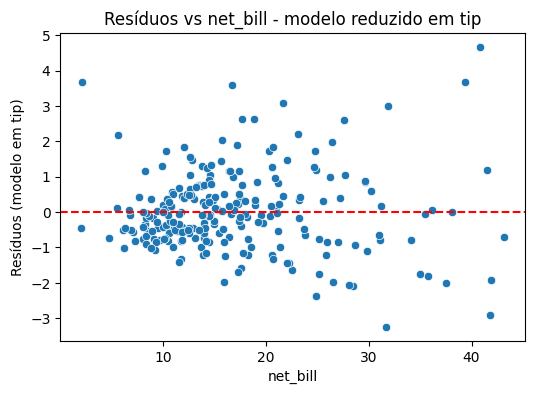

In [4]:
# I.3 Gráfico de resíduos em função de net_bill (modelo reduzido)

res_tip2 = reg_tip2.resid

plt.figure(figsize=(6, 4))
sns.scatterplot(x=tips["net_bill"], y=res_tip2)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("net_bill")
plt.ylabel("Resíduos (modelo em tip)")
plt.title("Resíduos vs net_bill - modelo reduzido em tip")
plt.show()

In [5]:
# I.4(a) Modelo com transformação log em net_bill

y_tip_logx, X_tip_logx = patsy.dmatrices(
    "tip ~ smoker + time + log_net_bill", data=tips
)
reg_tip_logx = sm.OLS(y_tip_logx, X_tip_logx).fit()
print(reg_tip_logx.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     33.55
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.79e-18
Time:                        18:13:39   Log-Likelihood:                -382.22
No. Observations:                 244   AIC:                             772.4
Df Residuals:                     240   BIC:                             786.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.3169      0.449     -2.

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     30.32
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.07e-20
Time:                        18:13:39   Log-Likelihood:                -374.88
No. Observations:                 244   AIC:                             759.8
Df Residuals:                     239   BIC:                             777.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.98

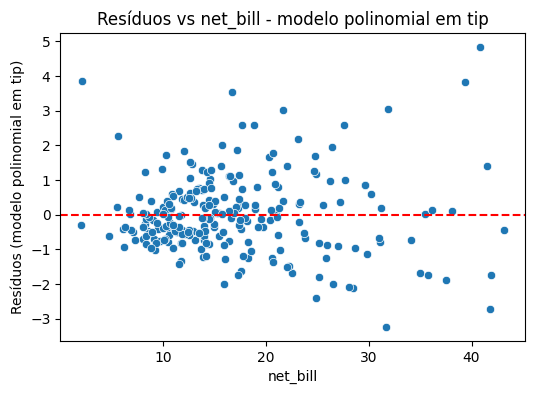

In [6]:
# I.4(b) Modelo polinomial em net_bill

y_tip_poly, X_tip_poly = patsy.dmatrices(
    "tip ~ smoker + time + net_bill + np.power(net_bill, 2)", data=tips
)
reg_tip_poly = sm.OLS(y_tip_poly, X_tip_poly).fit()
print(reg_tip_poly.summary())

# Resíduos do modelo polinomial
res_tip_poly = reg_tip_poly.resid

plt.figure(figsize=(6, 4))
sns.scatterplot(x=tips["net_bill"], y=res_tip_poly)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("net_bill")
plt.ylabel("Resíduos (modelo polinomial em tip)")
plt.title("Resíduos vs net_bill - modelo polinomial em tip")
plt.show()

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

In [7]:
# II.1 Matriz de design e modelo inicial: log_tip ~ sex + smoker + time + net_bill

tips["log_tip"] = np.log(tips["tip"])

y_log1, X_log1 = patsy.dmatrices(
    "log_tip ~ sex + smoker + time + net_bill", data=tips
)
reg_log1 = sm.OLS(y_log1, X_log1).fit()
print(reg_log1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     27.25
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.21e-18
Time:                        18:13:39   Log-Likelihood:                -97.419
No. Observations:                 244   AIC:                             204.8
Df Residuals:                     239   BIC:                             222.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4504      0.078      5.

In [8]:
# II.2 Modelo reduzido (remoção de variáveis não significantes)

y_log2, X_log2 = patsy.dmatrices(
    "log_tip ~ smoker + time + net_bill", data=tips
)
reg_log2 = sm.OLS(y_log2, X_log2).fit()
print(reg_log2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     36.48
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.84e-19
Time:                        18:13:39   Log-Likelihood:                -97.423
No. Observations:                 244   AIC:                             202.8
Df Residuals:                     240   BIC:                             216.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4534      0.071      6.

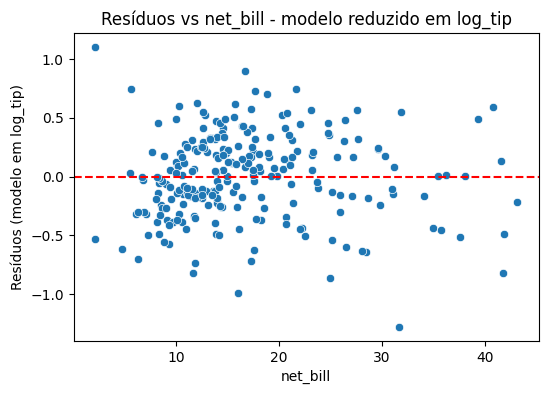

In [9]:
# II.3 Gráfico de resíduos em função de net_bill (modelo reduzido)

res_log2 = reg_log2.resid

plt.figure(figsize=(6, 4))
sns.scatterplot(x=tips["net_bill"], y=res_log2)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("net_bill")
plt.ylabel("Resíduos (modelo em log_tip)")
plt.title("Resíduos vs net_bill - modelo reduzido em log_tip")
plt.show()

In [10]:
# II.4(a) Modelo em log_tip com log_net_bill

y_log_logx, X_log_logx = patsy.dmatrices(
    "log_tip ~ smoker + time + log_net_bill", data=tips
)
reg_log_logx = sm.OLS(y_log_logx, X_log_logx).fit()
print(reg_log_logx.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     37.63
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.72e-20
Time:                        18:13:40   Log-Likelihood:                -96.227
No. Observations:                 244   AIC:                             200.5
Df Residuals:                     240   BIC:                             214.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4118      0.139     -2.

In [11]:
# II.4(b) Modelo em log_tip com polinômio em net_bill

y_log_poly, X_log_poly = patsy.dmatrices(
    "log_tip ~ smoker + time + net_bill + np.power(net_bill, 2)", data=tips
)
reg_log_poly = sm.OLS(y_log_poly, X_log_poly).fit()
print(reg_log_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     30.57
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.49e-20
Time:                        18:13:40   Log-Likelihood:                -92.851
No. Observations:                 244   AIC:                             195.7
Df Residuals:                     239   BIC:                             213.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.17

In [12]:
# II.5 Cálculo do R² em tip (sem log) para o modelo final

# Usamos o modelo com log_net_bill (reg_log_logx)
log_pred = reg_log_logx.fittedvalues

tip_pred_from_log = np.exp(log_pred)

y_tip_obs = tips["tip"]
SSE_tip = ((y_tip_obs - tip_pred_from_log) ** 2).sum()
SST_tip = ((y_tip_obs - y_tip_obs.mean()) ** 2).sum()
R2_tip_via_log = 1 - SSE_tip / SST_tip

print("R2 em tip via modelo log_tip ~ ... + log_net_bill:", R2_tip_via_log)
print("R2 do modelo direto tip ~ sex + smoker + time + net_bill:", reg_tip1.rsquared)

R2 em tip via modelo log_tip ~ ... + log_net_bill: 0.3047140012258902
R2 do modelo direto tip ~ sex + smoker + time + net_bill: 0.33524792271723225


### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [13]:
# III.1 Carregar a base de renda e ajustar o modelo simples

# Ajuste o caminho caso necessário
renda_df = pd.read_csv("../Mod10/previsao_de_renda.csv")

# Remove observações sem renda ou tempo_emprego
renda_df = renda_df.dropna(subset=["renda", "tempo_emprego"])

reg_renda_simples = smf.ols("renda ~ tempo_emprego", data=renda_df).fit()
print(reg_renda_simples.summary())

                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     2294.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:13:40   Log-Likelihood:            -1.2249e+05
No. Observations:               12466   AIC:                         2.450e+05
Df Residuals:                   12464   BIC:                         2.450e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2653.9453     60.924     43.561

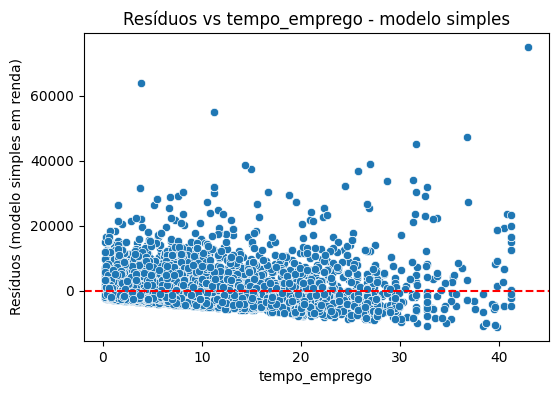

In [14]:
# III.2 Análise de resíduos do modelo simples

res_renda = reg_renda_simples.resid

plt.figure(figsize=(6, 4))
sns.scatterplot(x=renda_df["tempo_emprego"], y=res_renda)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("tempo_emprego")
plt.ylabel("Resíduos (modelo simples em renda)")
plt.title("Resíduos vs tempo_emprego - modelo simples")
plt.show()

In [15]:
# III.3 Regressão múltipla para log_renda

renda_df["log_renda"] = np.log(renda_df["renda"])

formula_full = (
    "log_renda ~ sexo + posse_de_veiculo + posse_de_imovel + "
    "qtd_filhos + tipo_renda + educacao + estado_civil + "
    "tipo_residencia + idade + tempo_emprego + qt_pessoas_residencia"
)

reg_renda_mult = smf.ols(formula_full, data=renda_df).fit()
print(reg_renda_mult.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     165.3
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:13:41   Log-Likelihood:                -13204.
No. Observations:               12466   AIC:                         2.646e+04
Df Residuals:                   12441   BIC:                         2.664e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [16]:
# III.4 Modelo reduzido (remoção de variáveis não significantes)

formula_reduced = (
    "log_renda ~ sexo + posse_de_imovel + tipo_renda + "
    "educacao + idade + tempo_emprego"
)

reg_renda_mult_red = smf.ols(formula_reduced, data=renda_df).fit()
print(reg_renda_mult_red.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     328.5
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:13:41   Log-Likelihood:                -13215.
No. Observations:               12466   AIC:                         2.646e+04
Df Residuals:                   12453   BIC:                         2.655e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

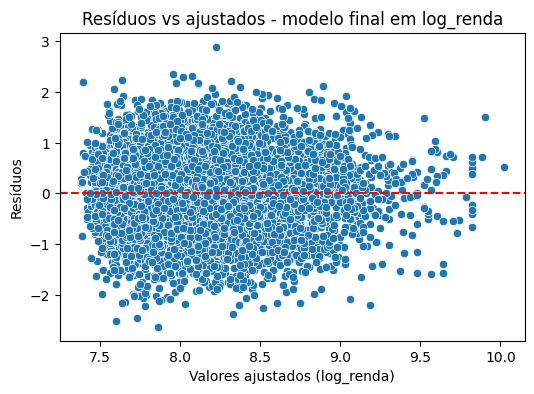

In [17]:
# III.5 Análise de resíduos do modelo final em log_renda

res_final = reg_renda_mult_red.resid
fitted_final = reg_renda_mult_red.fittedvalues

plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted_final, y=res_final)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Valores ajustados (log_renda)")
plt.ylabel("Resíduos")
plt.title("Resíduos vs ajustados - modelo final em log_renda")
plt.show()